### Imports

In [2]:
# import required libraries
import sys
sys.path.append("..")
import os
import random

from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# from model import SignLanguageCNN

%matplotlib inline

### Hyperparameters & Configurations

In [3]:
MODEL_TYPE = 'simple_cnn'

IMG_SIZE = 200
BATCH_SIZE = 32
EPOCHS = 40
LR = 0.0001

# data split ratios
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# data path
DATA_DIR = "../data/asl_alphabet_train"
CROP_PADDING = 10

### Reproducibility & Device setup

In [4]:
# set random seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"All random seeds are set to {seed}")

All random seeds are set to 42


In [5]:
# device setup
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Load Raw Dataset & Visualise Samples

In [6]:
# Load raw dataset (without transforms)
raw_dataset = datasets.ImageFolder(DATA_DIR)
num_classes = len(raw_dataset.classes)

print(f"Total No. of Classes: {num_classes}")
print(f"Classes: {raw_dataset.classes}")

Total No. of Classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


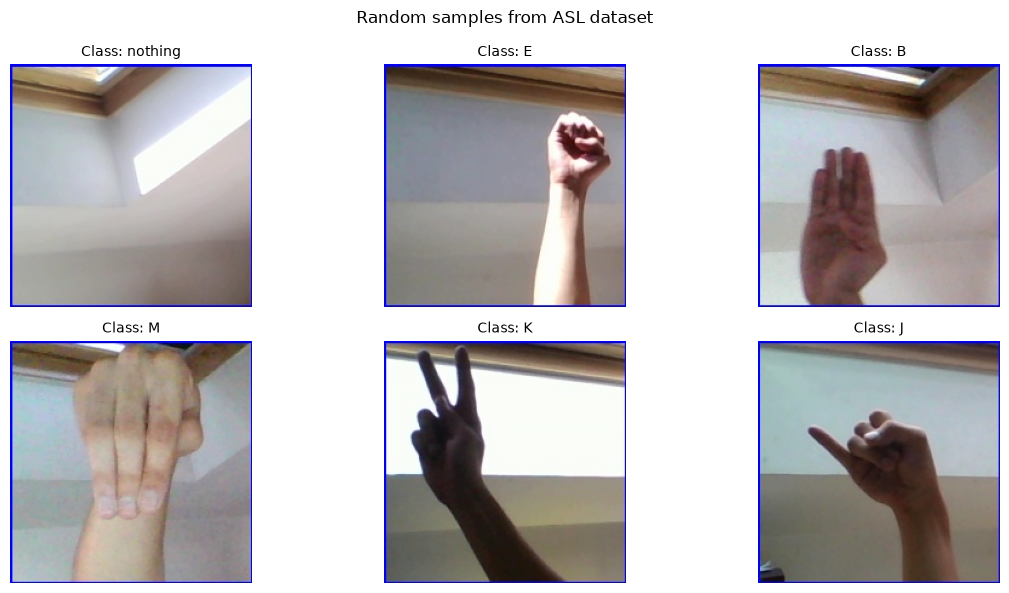

In [6]:
# visualize random samples
num_images = 6
plt.figure(figsize=(12,6))

for i in range(num_images):
    idx = random.randint(0, len(raw_dataset) - 1)
    img, label = raw_dataset[idx]
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {raw_dataset.classes[label]}", fontsize=10)
    plt.axis("off")

plt.suptitle("Random samples from ASL dataset", fontsize=12)
plt.tight_layout()
plt.show()

#### Bar Chart

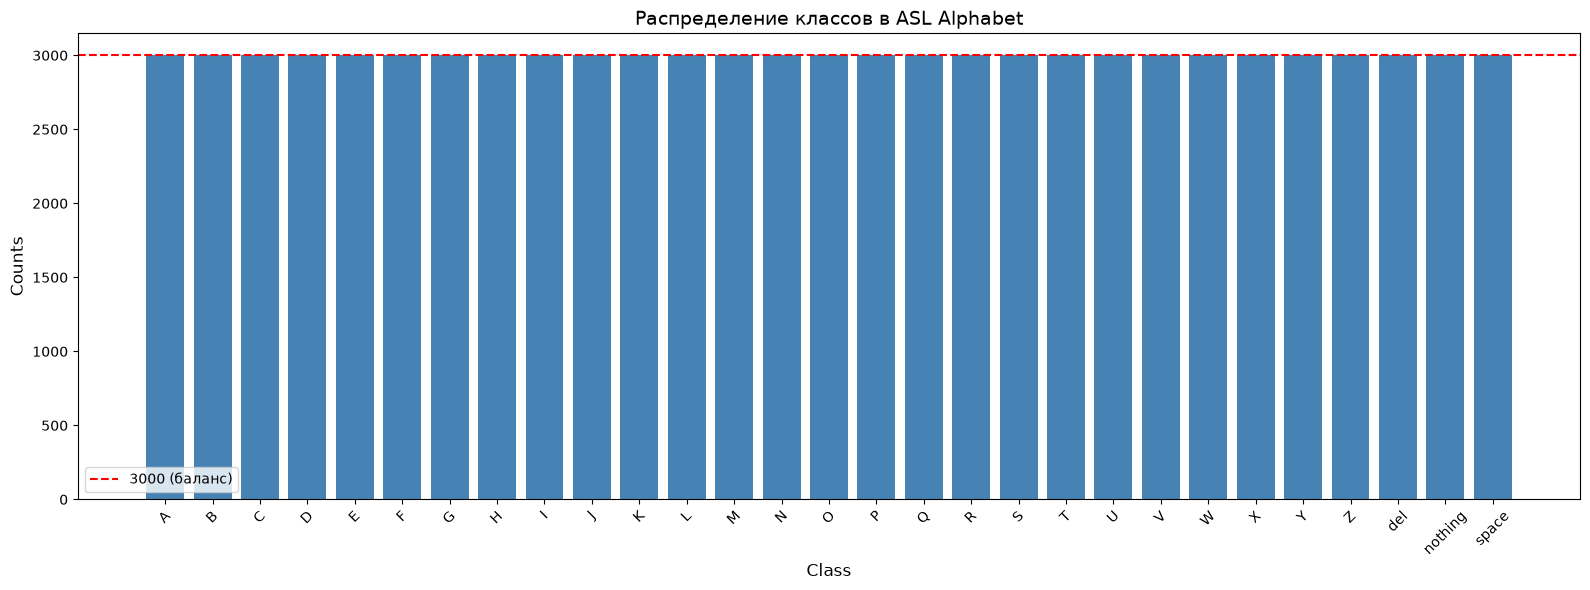

min: 3000, max: 3000, mean: 3000


In [7]:
classes = raw_dataset.classes
counts = [len(list((Path(DATA_DIR) / cls).glob("*.jpg"))) for cls in classes]
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(classes, counts, color="steelblue")
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Counts", fontsize=12)
ax.set_title("Распределение классов в ASL Alphabet", fontsize=14)
ax.axhline(y=3000, color="red", linestyle="--", label="3000 (баланс)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150)
plt.show()

print(f"min: {min(counts)}, max: {max(counts)}, mean: {sum(counts)/len(counts):.0f}")

#### Examples of 29 classes

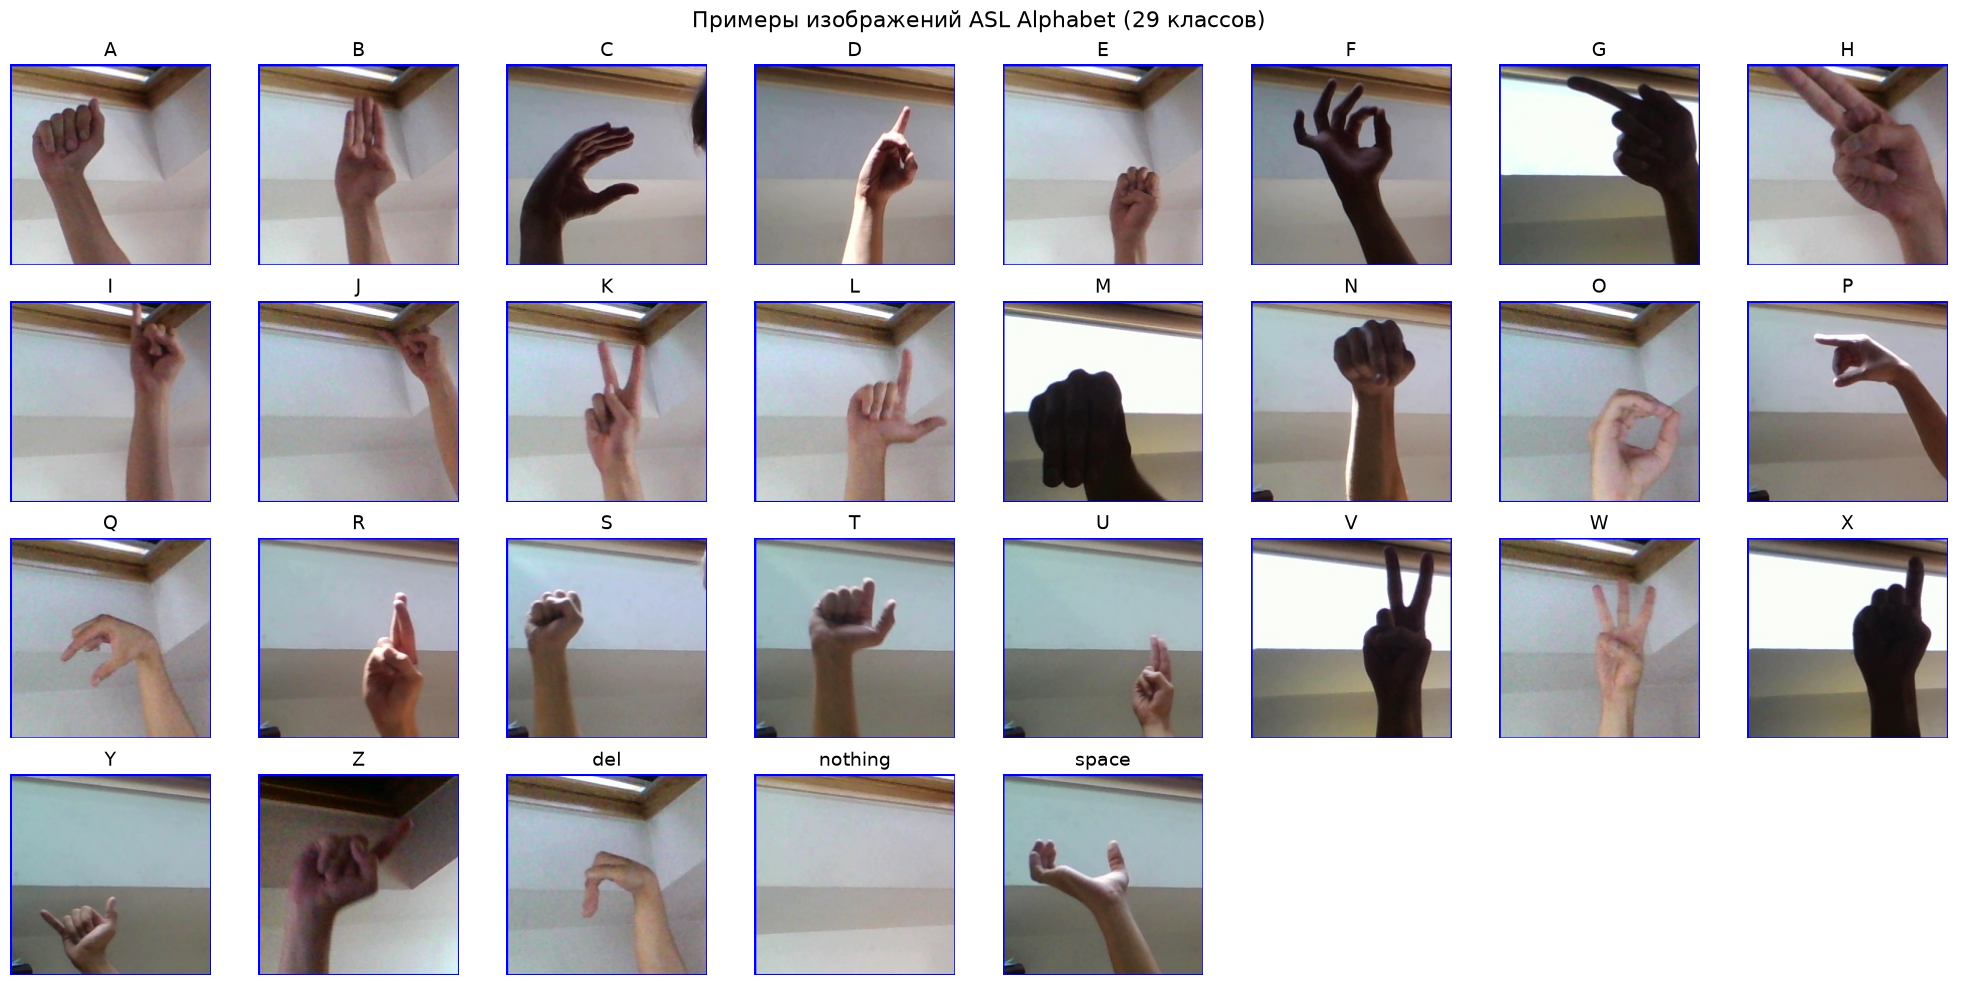

In [8]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    if i >= len(axes):
        break
    images = list((Path(DATA_DIR) / cls).glob("*.jpg"))
    img = Image.open(random.choice(images))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=14)
    axes[i].axis("off")

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Примеры изображений ASL Alphabet (29 классов)", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/figures/class_samples.png", dpi=150)
plt.show()

#### Dataset statistics

In [9]:
temp_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # 1 channel
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
temp_dataset = datasets.ImageFolder(DATA_DIR, temp_transform)
temp_loader = DataLoader(
    temp_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

n_pixels = 0
sum_x = 0.0
sum_x2 = 0.0

with torch.no_grad():
    for images, _ in temp_loader:
        images = images.to(device, non_blocking=True)
        sum_x += images.sum().item()
        sum_x2 += (images ** 2).sum().item()
        n_pixels += images.numel()

ASL_MEAN  = sum_x / n_pixels
var = sum_x2 / n_pixels - ASL_MEAN ** 2
ASL_STD  = var ** 0.5

print(f'mean={ASL_MEAN:.4f}, std={ASL_STD:.4f}')

mean=0.5068, std=0.2424


#### Распределение яркости

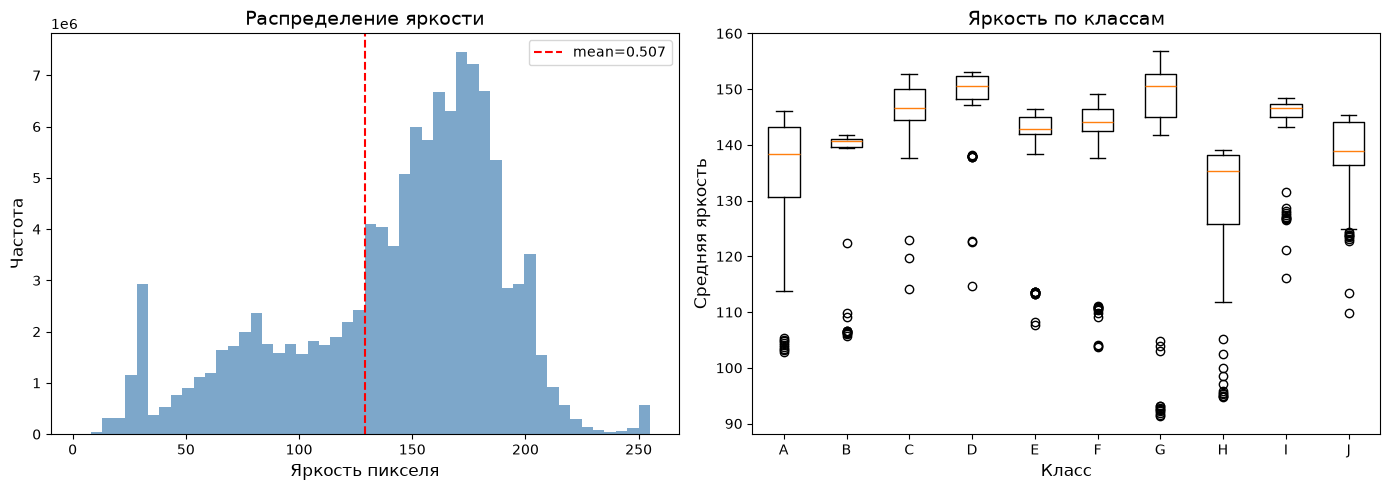

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_pixels = []
for cls in classes:
    for img_path in list((Path(DATA_DIR) / cls).glob("*.jpg"))[:100]:
        img = Image.open(img_path).convert("L")
        all_pixels.extend(np.array(img).flatten())

axes[0].hist(all_pixels, bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(x=ASL_MEAN * 255, color="red", linestyle="--", label=f"mean={ASL_MEAN:.3f}")
axes[0].set_xlabel("Яркость пикселя", fontsize=12)
axes[0].set_ylabel("Частота", fontsize=12)
axes[0].set_title("Распределение яркости", fontsize=14)
axes[0].legend()

# Box plot по классам
data_by_class = []
for cls in classes[:10]:
    pixels = []
    for img_path in list((Path(DATA_DIR) / cls).glob("*.jpg"))[:100]:
        img = Image.open(img_path).convert("L")
        pixels.append(np.array(img).mean())
    data_by_class.append(pixels)

axes[1].boxplot(data_by_class, tick_labels=classes[:10])
axes[1].set_xlabel("Класс", fontsize=12)
axes[1].set_ylabel("Средняя яркость", fontsize=12)
axes[1].set_title("Яркость по классам", fontsize=14)

plt.tight_layout()
plt.savefig("../reports/figures/brightness_distribution.png", dpi=150)
plt.show()

### Data Transforms

In [10]:
# transforms with augmentation
from src.data.transforms import get_transforms
train_transforms, val_transforms = get_transforms(
    model_type=MODEL_TYPE,
    img_size=IMG_SIZE,
    crop_padding=CROP_PADDING,
    mean=ASL_MEAN,
    std=ASL_STD
)

#### Visualize transfoms work

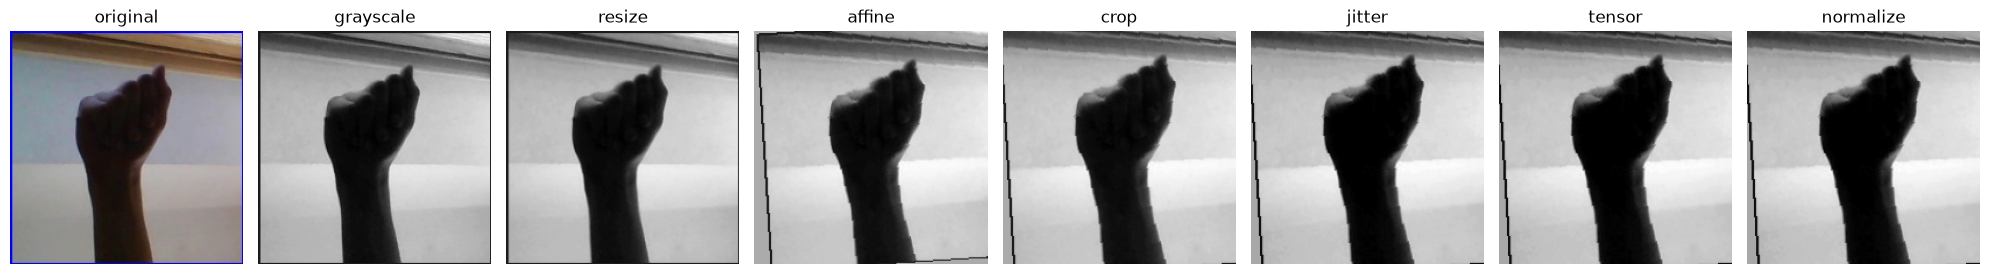

In [13]:
img = Image.open("../data/asl_alphabet_train/A/A1.jpg").convert("RGB")

steps = [
    ('original',  None),
    ('grayscale', transforms.Grayscale(num_output_channels=1)),
    ('resize',    transforms.Resize((IMG_SIZE + CROP_PADDING, IMG_SIZE + CROP_PADDING))),
    ('affine',    transforms.RandomAffine(15, translate=(0.05, 0.05), scale=(0.9, 1.1), fill=127)),
    ('crop',      transforms.CenterCrop(IMG_SIZE)),   
    ('jitter',    transforms.ColorJitter(brightness=0.2, contrast=0.2)),
    ('tensor',    transforms.ToTensor()),
    ('normalize', transforms.Normalize((ASL_MEAN,), (0.5,))),
]

fig, axes = plt.subplots(1, len(steps), figsize=(20, 4))

current = img
for ax, (name, tr) in zip(axes, steps):
    if tr is not None:
        current = tr(current)
    
    if isinstance(current, torch.Tensor):
        im_show = current.squeeze().numpy()
        # if name == 'normalize':
        #     im_show = im_show * ASL_STD + ASL_MEAN
        #     im_show = np.clip(im_show, 0, 1)
        ax.imshow(im_show, cmap='gray')
    else:
        if current.mode == 'RGB':
            ax.imshow(current)
        else:
            ax.imshow(current, cmap='gray')
    
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

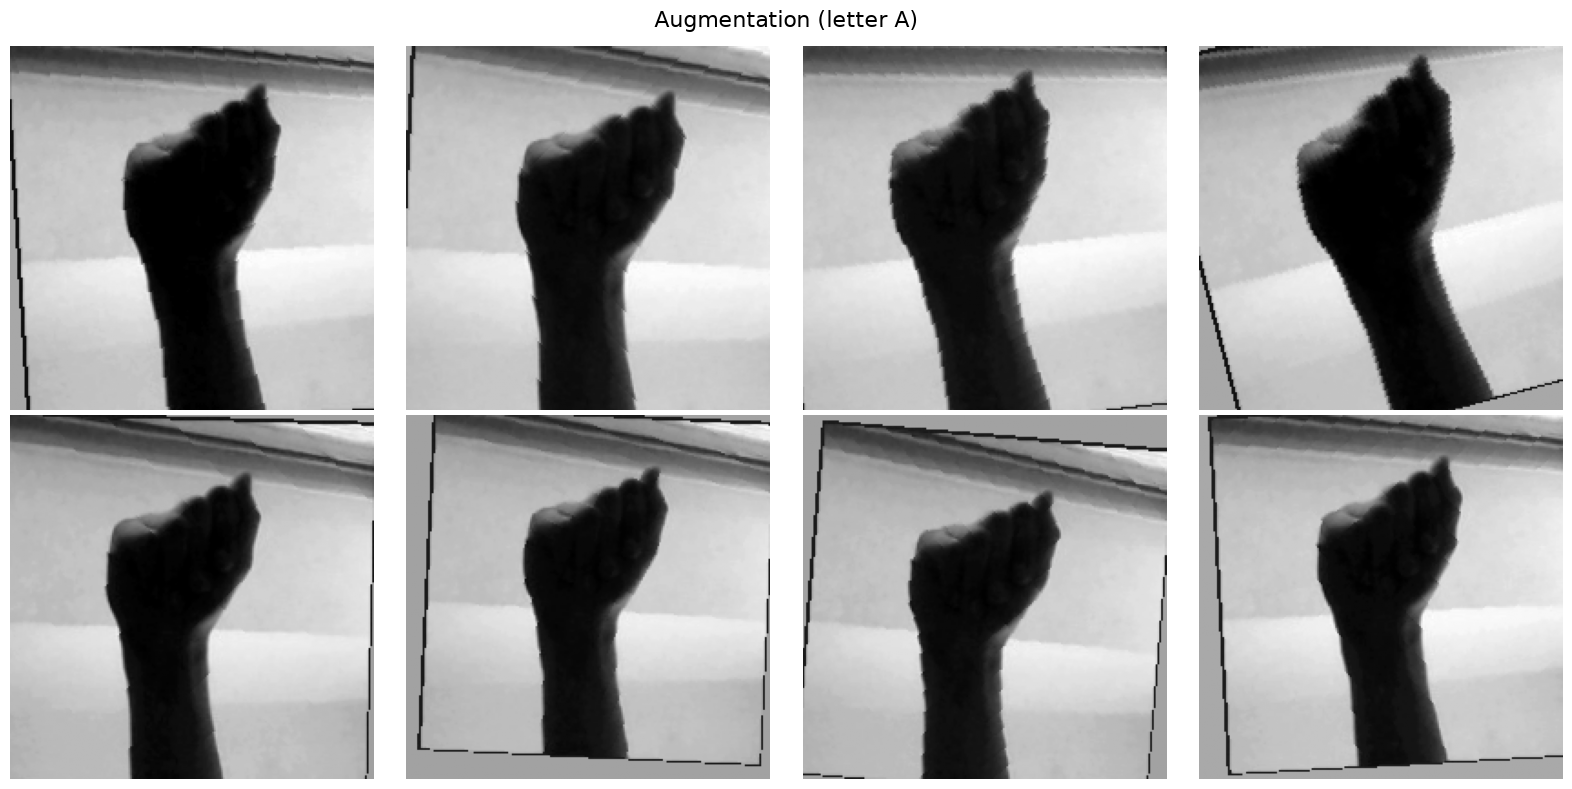

In [11]:
img = Image.open("../data/asl_alphabet_train/A/A1.jpg").convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.flat:
    aug_img = train_transforms(img)
    ax.imshow(aug_img.squeeze().numpy(), cmap='gray')
    ax.axis("off")
plt.suptitle("Augmentation (letter A)", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/figures/augmentation.png", dpi=150)
plt.show()

### Splitting Dataset

In [15]:
# load dataset with transforms
train_data_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
# val_data_full = datasets.ImageFolder(root=data_dir, transform=val_transforms)
# test_data_full = datasets.ImageFolder(root=data_dir, transform=val_transforms)

In [16]:
# split the data
dataset_size = len(train_data_full)
train_size = int(TRAIN_SPLIT * dataset_size) # 0.7
val_size = int(VAL_SPLIT * dataset_size) # 0.15
test_size = dataset_size - train_size - val_size # 0.15

generator = torch.Generator().manual_seed(seed)
train_ds, val_ds, test_ds = random_split(train_data_full, [train_size, val_size, test_size], generator=generator)

print(f"Total images: {dataset_size}")
print(f"Train: {len(train_ds)} ({len(train_ds)/dataset_size:.1%})")
print(f"Val:   {len(val_ds)} ({len(val_ds)/dataset_size:.1%})")
print(f"Test:  {len(test_ds)} ({len(test_ds)/dataset_size:.1%})")

Total images: 87000
Train: 60899 (70.0%)
Val:   13050 (15.0%)
Test:  13051 (15.0%)
